# Using Kernelized Ridge Regression for non-linear data

In this notebook I will show how to we can use kernelized ridge regression to obtain a similar results that can be achieved using polynomial ridge regression, when we want to find the best regressor for non-linear data. I will explain how standard ridge regression works and then how we can apply the kernel trick to perform implicitly the execution on a (higher-dimensional) feature space associated to a kernel. In fact, projecting the non-linear data into a higher dimensional feature space could allow to represents complex patterns linearly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import make_regression

# Creating an artificial dataset

In [2]:
np.random.seed(42)

def f(X):
  return np.sin(X * 1.5) # sine function with a different frequency

n_samples = 100
X = np.linspace(-5, 5, n_samples).reshape(-1, 1)
y_true = f(X).reshape(-1)
y = y_true + np.random.normal(scale=0.1, size=n_samples)  # add noise

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

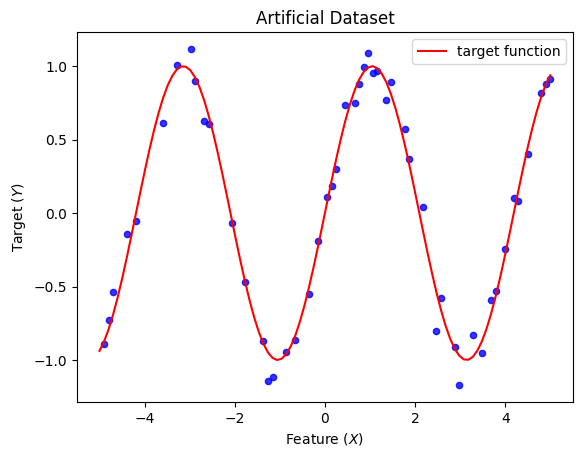

In [4]:
plt.scatter(X_train, y_train, color='blue', s=20, alpha=0.8)
plt.plot(X, y_true, color='red', label='target function')
plt.title('Artificial Dataset')
plt.xlabel('Feature ($X$)')
plt.ylabel('Target ($Y$)')
plt.legend()
plt.show()

# Standard ridge regression

Ridge regression is a linear model where the cost function is:
$$\min_{w} ||y - \mathbf{X} w||^2_2 + \alpha ||w||^2_2$$

The first term $||y - X w||^2_2$ measures how well the model fits the data meanwhile the second term $||w||^2_2$ penalizes large weights forcing the model coefficients to stay small, avoiding overfitting. $\alpha$ is the regularization strength, an hyperparameter that control the tradeoff between the two terms.

If $\alpha = 0$ we recover the ordinary least squares. With the dataset we created before that has a non-linear trend a standard ridge regression without introducing some polynomial features will fail to capture the underlying relationship in the data.

In [5]:
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, y_train)

Ridge(alpha=0.001)

In [6]:
y_pred_ridge = ridge_model.predict(X_test)

In [7]:
# to avoid that resulting line plot will zigzag
# the points are connected in the random order they appear in the array, not in order of increasing x
sort_idx = X_test.flatten().argsort()
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]
y_pred_ridge_sorted = y_pred_ridge[sort_idx]
# now the line follows the natural left-to-right order of the x-axis

As you can see from the plot, the model is not able to fit the data using a straight line as expected.

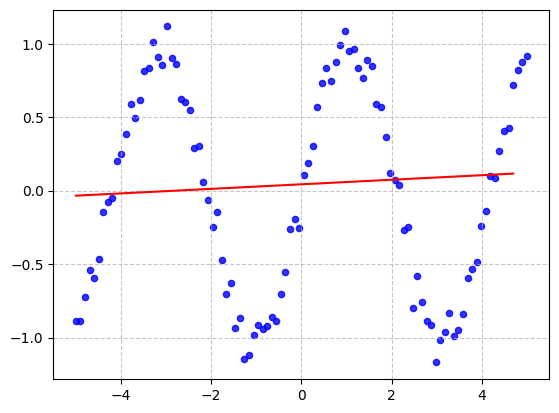

In [8]:
plt.plot(X_test_sorted, y_pred_ridge_sorted, color='red')
plt.scatter(X, y, color='blue', s=20, alpha=0.8)
plt.grid(True, linestyle='--', alpha=0.7)

To evaluate a regression model we can use $R^2$ (coefficient of determination) score that is:
$$
R^2 = 1 - \frac{SS_R}{SS_M}
$$

where $SS_R$ is the sum of squared error by regression line and $SS_M$ is the sum of squared error by mean line.

Basically $R^2$ score measures how well a regression model explains the variability of the target variable.

Conceptually, we can also think at the $R^2$ score as something like:

$$
R^2 = \frac{\text{Explained Variation}}{\text{Total Variation}}
$$

When $R^2 = 1$ it means that the model actually explains 100% of the variance in the target variable. When $R^2 = 0$ The model explains no more variance than the mean of target variable. Finally when $R^2 < 0$ The model performs worse than simply predicting the mean of the target variable.



In [9]:
r2_ridge = r2_score(y_test, y_pred_ridge)

For this particular standard ridge regression model we expect a very bad $R^2$ score.

In [10]:
print(f"R-squared for Ridge Regression (Linear): {r2_ridge:.4f}")

R-squared for Ridge Regression (Linear): -0.0581


# Kernelized Ridge Regression

One of the thing that we could do to improve our model is to introduce some polynomial feature so using (polynomial ridge regression), that is a non-linear model. But in this notebook we don't want to explicitly represent this polynomial features.

By mapping the data into a new feature space through a non-linear transformation, it is possible to find a regressor that fits the data more effectively.

The polynomial features represents some non-linear transformation of the initial data that we have. So here we want to use this non-linear transformation implicitly, without the necessity of representing the vectors in the feature space. The important thing is that we can express the ridge regression in terms of dot-products.

Any algorithm for vectorial data which can be expressed in terms of dot-products can be implicitly executed in the feature space associated to a kernel, by simply replacing dot-products with kernel evaluations. This is known as the Kernel Trick.




## How do we kernelized ridge regression?

Remember that in Ridge Regression the cost function is:
$$\min_{w} ||y - \mathbf{X} w||^2_2 + \lambda ||w||^2_2$$

The closed-form solution is:
$$w=(\mathbf{X}^\top\mathbf{X}+\lambda\mathbf{I})^{-1}\mathbf{X}^\top y$$

and the predictions are:
$$\hat{y}=w^{\mathrm{T}}\mathbf{x}$$

assuming that $\mathbf{x}_0 = 1$ and $w_0 = b$.

Now let's consider a non-linear feature mapping provided by $\phi(\mathbf{x})$.
Instead of working directly with $w$, we assume that it can expressed as:
$$w=\sum_{i=1}^n\alpha_i\phi(\mathbf{x}_i)$$

This is the core idea of the Representer Theorem, which states that the solution vector $\mathbf{w}$ can be expressed as a linear combination of the feature-mapped training samples. This moves us from the primal form (where we are learning weights to each feature) to a dual formulation where we learn weights (lagrange multipliers) for each training examples.

By plugging this back into the model's prediction function, we get:
$$\hat{y}(\mathbf{x})=w\cdot\phi(\mathbf{x})=\sum_{i=1}^n\alpha_i\phi(\mathbf{x}_i)\cdot\phi(\mathbf{x})$$
assuming that $\phi_0(x) = 1$ and $w_0 = b$. Now that we have a dot-product between vectors in feature space we can replace this dot-product with a kernel function:
$$K(\mathbf{x}_k,\mathbf{x})=\phi(\mathbf{x}_k)\cdot\phi(\mathbf{x})$$

So then:
$$\hat{y}(\mathbf{x})=w\cdot\phi(\mathbf{x})=\sum_{i=1}^n\alpha_iK(\mathbf{x}_i,\mathbf{x})$$

Remember that the kernel matrix $\mathbf{K}$ (also known as the Gram matrix) is an $n \times n$ matrix where each entry $\mathbf{K}_{ij}$ represents the similarity between two training points, $\mathbf{x}_i$ and $\mathbf{x}_j$, as calculated by the chosen kernel function.


## Polynomial Kernel

Now we can use Kernelized Ridge Regression (KRR) with a Polynomial kernel to achieve results that are functionally similar to running a standard Ridge Regression model on data that has been explicitly transformed using polynomial features.

Note that KRR achieves the result without ever calculating the feature vector obtained by some non-linear transformation on the initial data.

The polynomial kernel is defined as:
$$
K(\mathbf{x}, \mathbf{z}) = (\mathbf{x} \cdot \mathbf{z} + c)^s, \quad c > 0, \space s \in \mathbb{N}
$$

where $s$ is the degree of the polynomial kernel.



After playing a bit with the hyperparameters i chose a ```degree``` equal to 10 in fact increasing the polynomial degree allows the model to capture non-linear relationships that a low-degree polynomial would miss. It is evident that data are clearly non-linear therefore raising the degree is necessary to avoid underfitting.

Finally I chose an ```alpha``` equal to 1 for the regularization because it provides enough regularization to stabilize the solution while still allowing flexibility to fit complex data.

These results were confirmed using cross-validation through ```GridSearch```.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'degree': [2, 3, 5, 10],
    'kernel': ['polynomial'],
    'coef0': [1]
}

grid = GridSearchCV(KernelRidge(), param_grid, cv=5)
grid.fit(X_train, y_train)

In [12]:
print(grid.best_params_)

{'alpha': 1, 'coef0': 1, 'degree': 10, 'kernel': 'polynomial'}


In [13]:
krr_model = KernelRidge(alpha=1, kernel='polynomial', degree=10)
krr_model.fit(X_train, y_train)

KernelRidge(degree=10, kernel='polynomial')

In [14]:
y_pred_krr = krr_model.predict(X_test)

In [15]:
y_pred_krr_sorted = y_pred_krr[sort_idx]

As we can notice the model corresponds to a linear regressor in the feature space, which translates into a nonlinear regressor in the original input space that we are plotting.

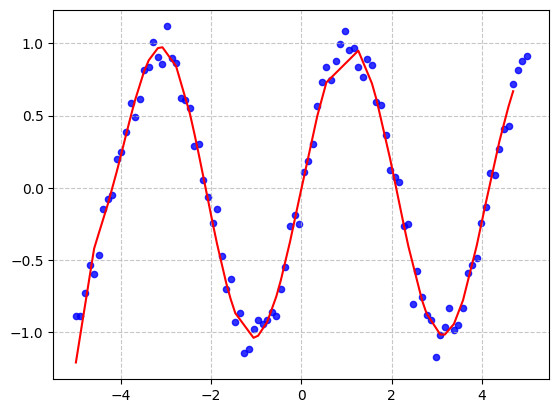

In [16]:
plt.plot(X_test_sorted, y_pred_krr_sorted, color='red',)
plt.scatter(X, y, color='blue', s=20, alpha=0.8)
plt.grid(True, linestyle='--', alpha=0.7)

Finally we can compute $R^2$ score now, it should be much better than the score obtained with standard ridge regression.

In [17]:
r2_krr = r2_score(y_test, y_pred_krr)

In [18]:
print(f"R-squared for Kernelized Ridge Regression: {r2_krr:.4f}")

R-squared for Kernelized Ridge Regression: 0.9759


$R^2$ score is approaching 1 so then we can say that the regression model is doing an excellent job at explaining the variability in the target variable.

# The comparison

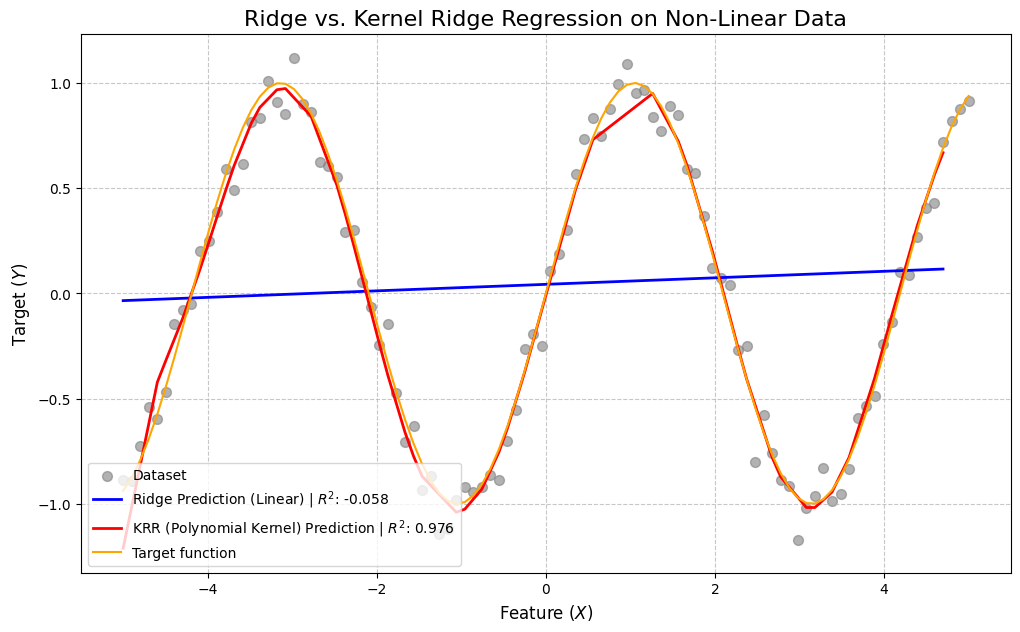

In [19]:
plt.figure(figsize=(12, 7))

# Plot 1: Dataset
plt.scatter(X, y, color='gray', s=50, alpha=0.6, label='Dataset')

# Plot 2: Ridge Prediction (Linear Fit)
plt.plot(X_test_sorted, y_pred_ridge_sorted, color='blue', linewidth=2,
         label=f'Ridge Prediction (Linear) | $R^2$: {r2_ridge:.3f}')

# Plot 3: KRR Prediction (Non-Linear Fit)
plt.plot(X_test_sorted, y_pred_krr_sorted, color='red', linewidth=2,
         label=f'KRR (Polynomial Kernel) Prediction | $R^2$: {r2_krr:.3f}')

# Plot 4: Target function
plt.plot(X, y_true, color='orange', label='Target function')

plt.title('Ridge vs. Kernel Ridge Regression on Non-Linear Data', fontsize=16)
plt.xlabel('Feature ($X$)', fontsize=12)
plt.ylabel('Target ($Y$)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Conclusion

In this notebook, we demonstrated that standard Ridge Regression is ineffective when learning non-linear patterns in data, as expected. Instead of explicitly computing polynomial features, we can leverage the kernel trick to project the data into a higher-dimensional feature space, where the underlying relationships may become linear.
In that new space, we can then effectively apply a linear model. Importantly, we do not need to explicitly define or compute the non-linear transformations of the data because the kernel function allows us to implicitly perform this mapping and run a linear model in the transformed feature space through kernel evaluations. Finally, we showed that the kernelized version of Ridge Regression is sufficient to capture and learn non-linear patterns in the data.

# References

ML Lab 1

Slide Lez10-11 SVM

https://medium.com/@deependra.verma00/r2-score-linear-regression-e095a1188e87

https://scikit-learn.org/stable/modules/kernel_ridge.html